# Notebook 02. Exploratory Data Analysis for MoA Prediction

This notebook performs structured exploratory data analysis for the MoA Prediction project.

The goal is to understand the dataset patterns before feature engineering and model training.

This EDA will focus on:

- experimental metadata structure,
- scored and nonscored target behavior,
- multi-label target sparsity,
- gene expression feature patterns,
- cell viability feature patterns,
- train-test distribution consistency,
- target co-occurrence,
- representation structure using PCA,
- and feature engineering decisions.

This notebook will not train models.  
This notebook will not create final model-ready features.  
Those steps will be handled in later notebooks.

### Import libraries and define paths

In [1]:
from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)

sns.set_theme(style="whitegrid")

PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

INTERIM_DATA_DIR = PROJECT_ROOT / "data" / "interim"
FIGURE_DIR = PROJECT_ROOT / "outputs" / "figures"

FIGURE_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Interim data folder:", INTERIM_DATA_DIR)
print("Figure output folder:", FIGURE_DIR)

Project root: c:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\Machine_Learning\moa-prediction-drug-response
Interim data folder: c:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\Machine_Learning\moa-prediction-drug-response\data\interim
Figure output folder: c:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\Machine_Learning\moa-prediction-drug-response\outputs\figures


## 0.1 Load Clean Interim Data

In the previous notebook, we completed data integration and saved clean interim files.

In this EDA notebook, we will load those clean files directly from `data/interim/`.

We will not reload raw CSV files here because data validation and integration were already completed in Notebook 01.

In [2]:
train_features = pd.read_parquet(INTERIM_DATA_DIR / "train_features_clean.parquet")
test_features = pd.read_parquet(INTERIM_DATA_DIR / "test_features_clean.parquet")

y_scored = pd.read_parquet(INTERIM_DATA_DIR / "y_scored.parquet")
y_nonscored = pd.read_parquet(INTERIM_DATA_DIR / "y_nonscored.parquet")

train_drug = pd.read_parquet(INTERIM_DATA_DIR / "train_drug_clean.parquet")
train_main_scored = pd.read_parquet(INTERIM_DATA_DIR / "train_main_scored.parquet")
train_with_drug = pd.read_parquet(INTERIM_DATA_DIR / "train_with_drug.parquet")

with open(INTERIM_DATA_DIR / "feature_groups.json", "r") as f:
    feature_groups = json.load(f)

print("Clean interim data loaded successfully.")

Clean interim data loaded successfully.


## 0.2 EDA Asset Overview

Before starting analysis, we check the shapes of the clean files loaded for EDA.

This confirms that the EDA notebook is using the correct outputs from the data integration notebook.

In [3]:
eda_asset_overview = pd.DataFrame({
    "asset_name": [
        "train_features",
        "test_features",
        "y_scored",
        "y_nonscored",
        "train_drug",
        "train_main_scored",
        "train_with_drug",
    ],
    "rows": [
        train_features.shape[0],
        test_features.shape[0],
        y_scored.shape[0],
        y_nonscored.shape[0],
        train_drug.shape[0],
        train_main_scored.shape[0],
        train_with_drug.shape[0],
    ],
    "columns": [
        train_features.shape[1],
        test_features.shape[1],
        y_scored.shape[1],
        y_nonscored.shape[1],
        train_drug.shape[1],
        train_main_scored.shape[1],
        train_with_drug.shape[1],
    ],
})

eda_asset_overview

,asset_name,rows,columns
0,train_features,23814,876
1,test_features,3982,876
2,y_scored,23814,207
3,y_nonscored,23814,403
4,train_drug,23814,2
5,train_main_scored,23814,1082
6,train_with_drug,23814,877


## 0.3 Load Feature Groups

The previous notebook saved the feature groups in `feature_groups.json`.

We load those groups here so that every analysis uses the same column definitions.

In [4]:
ID_COL = feature_groups["id_col"]

metadata_features = feature_groups["metadata_features"]
gene_features = feature_groups["gene_features"]
cell_features = feature_groups["cell_features"]

scored_target_features = feature_groups["scored_target_features"]
nonscored_target_features = feature_groups["nonscored_target_features"]

feature_group_check = pd.DataFrame({
    "group": [
        "ID column",
        "metadata features",
        "gene features",
        "cell features",
        "scored targets",
        "nonscored targets",
    ],
    "count": [
        1,
        len(metadata_features),
        len(gene_features),
        len(cell_features),
        len(scored_target_features),
        len(nonscored_target_features),
    ]
})

feature_group_check

,group,count
0,ID column,1
1,metadata features,3
2,gene features,772
3,cell features,100
4,scored targets,206
5,nonscored targets,402


## 2. Experimental Design and Metadata Audit

The MoA dataset contains three important metadata columns:

- `cp_type`: treatment type
- `cp_time`: treatment duration
- `cp_dose`: treatment dose

These columns describe the experimental condition for each biological sample.

Before analyzing targets or biological features, we first check whether the experimental setup is balanced and whether train and test metadata distributions are similar.

This section helps us decide:

- how metadata should be encoded later,
- whether train and test have distribution shift,
- whether control samples need special treatment,
- and whether metadata interaction features may be useful.

### 2.1 Metadata Cardinality Check

First, we check the number of unique values in each metadata column for both train and test data.

This confirms whether the metadata columns contain the expected categories and whether train/test categories match.

In [5]:
metadata_cardinality_report = []

for col in metadata_features:
    train_unique = sorted(train_features[col].unique().tolist())
    test_unique = sorted(test_features[col].unique().tolist())
    
    metadata_cardinality_report.append({
        "column": col,
        "train_unique_count": train_features[col].nunique(),
        "test_unique_count": test_features[col].nunique(),
        "train_unique_values": train_unique,
        "test_unique_values": test_unique,
        "same_categories": set(train_unique) == set(test_unique),
    })

metadata_cardinality_report = pd.DataFrame(metadata_cardinality_report)
metadata_cardinality_report

,column,train_unique_count,test_unique_count,train_unique_values,test_unique_values,same_categories
0,cp_type,2,2,"[ctl_vehicle, trt_cp]","[ctl_vehicle, trt_cp]",True
1,cp_time,3,3,"[24, 48, 72]","[24, 48, 72]",True
2,cp_dose,2,2,"[D1, D2]","[D1, D2]",True


### 2.2 Train vs Test Metadata Distribution

Next, we compare the percentage distribution of metadata categories between train and test data.

Counts alone can be misleading because train and test have different row counts.  
So we compare percentages instead of only raw counts.

In [6]:
def metadata_distribution_table(train_df, test_df, column):
    train_dist = (
        train_df[column]
        .value_counts(normalize=True)
        .mul(100)
        .rename("train_percent")
        .rename_axis("category")
        .reset_index()
    )
    
    test_dist = (
        test_df[column]
        .value_counts(normalize=True)
        .mul(100)
        .rename("test_percent")
        .rename_axis("category")
        .reset_index()
    )
    
    table = train_dist.merge(
        test_dist,
        on="category",
        how="outer"
    ).fillna(0)
    
    table["percent_difference"] = table["test_percent"] - table["train_percent"]
    table.insert(0, "metadata_column", column)
    
    return table


metadata_distribution_tables = []

for col in metadata_features:
    metadata_distribution_tables.append(
        metadata_distribution_table(train_features, test_features, col)
    )

metadata_distribution_comparison = pd.concat(
    metadata_distribution_tables,
    axis=0,
    ignore_index=True
)

metadata_distribution_comparison

,metadata_column,category,train_percent,test_percent,percent_difference
0,cp_type,ctl_vehicle,7.835727,8.990457,1.154730
1,cp_type,trt_cp,92.164273,91.009543,-1.154730
2,cp_time,24,32.636264,32.646911,0.010647
3,cp_time,48,34.643487,34.580613,-0.062874
4,cp_time,72,32.720249,32.772476,0.052228
5,cp_dose,D1,51.007811,50.904068,-0.103742
6,cp_dose,D2,48.992189,49.095932,0.103742


### 2.3 Visualize Train vs Test Metadata Distribution

Now we visualize train and test metadata distributions using percentage bar plots.

The purpose is to quickly see whether train and test have similar experimental setups.

These plots are more useful than raw count plots because train and test have different numbers of rows.

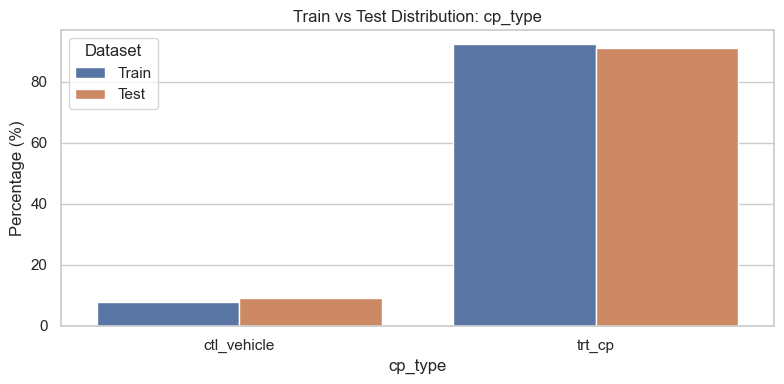

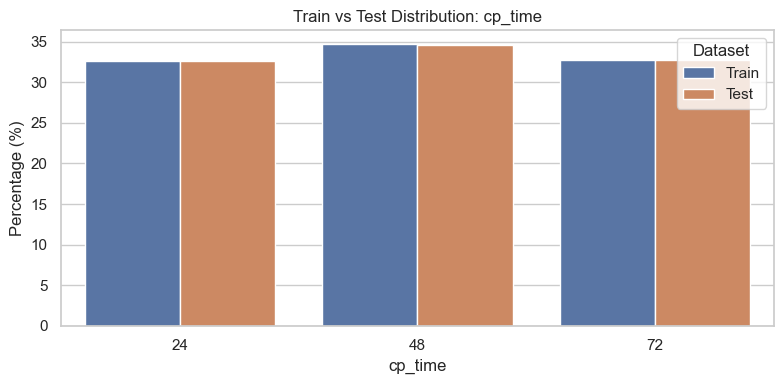

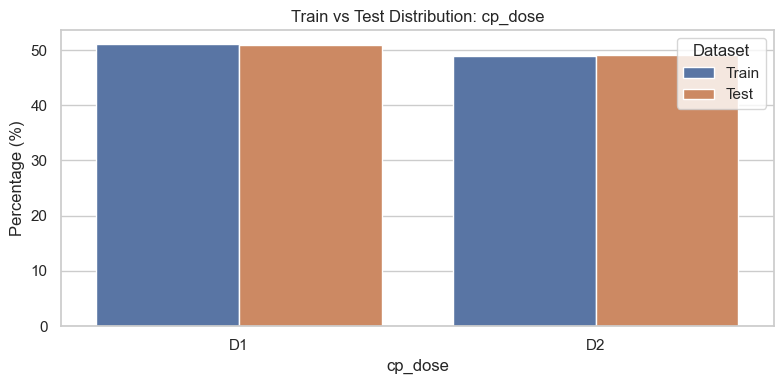

In [7]:
def plot_train_test_metadata_distribution(comparison_df, column):
    plot_df = comparison_df[comparison_df["metadata_column"] == column].copy()
    
    plot_df_long = plot_df.melt(
        id_vars=["category"],
        value_vars=["train_percent", "test_percent"],
        var_name="dataset",
        value_name="percentage"
    )
    
    plot_df_long["dataset"] = plot_df_long["dataset"].replace({
        "train_percent": "Train",
        "test_percent": "Test"
    })
    
    plt.figure(figsize=(8, 4))
    sns.barplot(
        data=plot_df_long,
        x="category",
        y="percentage",
        hue="dataset"
    )
    
    plt.title(f"Train vs Test Distribution: {column}")
    plt.xlabel(column)
    plt.ylabel("Percentage (%)")
    plt.legend(title="Dataset")
    plt.tight_layout()
    plt.show()


for col in metadata_features:
    plot_train_test_metadata_distribution(metadata_distribution_comparison, col)

### 2.4 Metadata Analysis: Initial Insights

The metadata distribution comparison shows that train and test have very similar experimental setups.

The `cp_time` and `cp_dose` distributions are almost identical between train and test.  
The `cp_type` distribution has a small difference: test data contains slightly more control samples and slightly fewer treated samples compared with train data.

This difference is small and does not indicate a serious metadata shift.

Key decisions from this section:

- `cp_type`, `cp_time`, and `cp_dose` should be kept as important metadata features.
- These metadata columns should be encoded during feature engineering.
- `ctl_vehicle` control samples should be handled carefully because they have no active MoA targets.
- Interaction features such as `cp_time × cp_dose` may be useful and should be explored next.

### 2.5 Metadata Interaction Analysis

Now we analyze combinations of metadata features.

Single metadata columns looked balanced, but we also need to check whether combinations such as `cp_time × cp_dose` are balanced.

This helps us understand the experimental design more clearly and decide whether interaction features may be useful later.

In [8]:
metadata_interaction_pairs = [
    ("cp_time", "cp_dose"),
    ("cp_type", "cp_time"),
    ("cp_type", "cp_dose"),
]

interaction_tables = {}

for col1, col2 in metadata_interaction_pairs:
    interaction_name = f"{col1}_x_{col2}"
    
    interaction_table = (
        train_features
        .groupby([col1, col2])
        .size()
        .reset_index(name="train_count")
    )
    
    interaction_table["train_percent"] = (
        interaction_table["train_count"] / len(train_features) * 100
    )
    
    interaction_tables[interaction_name] = interaction_table
    
    print(f"\n{interaction_name}")
    display(interaction_table)


cp_time_x_cp_dose


,cp_time,cp_dose,train_count,train_percent
0,24,D1,3886,16.318132
1,24,D2,3886,16.318132
2,48,D1,4354,18.283363
3,48,D2,3896,16.360124
4,72,D1,3907,16.406316
5,72,D2,3885,16.313933



cp_type_x_cp_time


,cp_type,cp_time,train_count,train_percent
0,ctl_vehicle,24,606,2.544722
1,ctl_vehicle,48,648,2.721088
2,ctl_vehicle,72,612,2.569917
3,trt_cp,24,7166,30.091543
4,trt_cp,48,7602,31.922399
5,trt_cp,72,7180,30.150332



cp_type_x_cp_dose


,cp_type,cp_dose,train_count,train_percent
0,ctl_vehicle,D1,951,3.993449
1,ctl_vehicle,D2,915,3.842278
2,trt_cp,D1,11196,47.014361
3,trt_cp,D2,10752,45.149912


### 2.5.1 Train vs Test Metadata Interaction Comparison

Now we compare metadata interaction percentages between train and test.

This helps us check whether train and test have similar experimental combinations, not only similar individual metadata columns.

In [9]:
def interaction_distribution_table(train_df, test_df, col1, col2):
    train_dist = (
        train_df
        .groupby([col1, col2])
        .size()
        .reset_index(name="train_count")
    )
    train_dist["train_percent"] = train_dist["train_count"] / len(train_df) * 100

    test_dist = (
        test_df
        .groupby([col1, col2])
        .size()
        .reset_index(name="test_count")
    )
    test_dist["test_percent"] = test_dist["test_count"] / len(test_df) * 100

    table = train_dist.merge(
        test_dist,
        on=[col1, col2],
        how="outer"
    ).fillna(0)

    table["percent_difference"] = table["test_percent"] - table["train_percent"]
    table.insert(0, "interaction", f"{col1}_x_{col2}")

    return table


interaction_comparison_tables = []

for col1, col2 in metadata_interaction_pairs:
    interaction_comparison_tables.append(
        interaction_distribution_table(train_features, test_features, col1, col2)
    )

metadata_interaction_comparison = pd.concat(
    interaction_comparison_tables,
    axis=0,
    ignore_index=True
)

metadata_interaction_comparison

,interaction,cp_time,cp_dose,train_count,train_percent,test_count,test_percent,percent_difference,cp_type
0,cp_time_x_cp_dose,24.0,D1,3886,16.318132,648,16.273230,-0.044903,NaN
1,cp_time_x_cp_dose,24.0,D2,3886,16.318132,652,16.373682,0.055549,NaN
2,cp_time_x_cp_dose,48.0,D1,4354,18.283363,725,18.206931,-0.076432,NaN
3,cp_time_x_cp_dose,48.0,D2,3896,16.360124,652,16.373682,0.013557,NaN
4,cp_time_x_cp_dose,72.0,D1,3907,16.406316,654,16.423908,0.017592,NaN
5,cp_time_x_cp_dose,72.0,D2,3885,16.313933,651,16.348569,0.034636,NaN
6,cp_type_x_cp_time,24.0,NaN,606,2.544722,116,2.913109,0.368387,ctl_vehicle
7,cp_type_x_cp_time,48.0,NaN,648,2.721088,124,3.114013,0.392925,ctl_vehicle
8,cp_type_x_cp_time,72.0,NaN,612,2.569917,118,2.963335,0.393418,ctl_vehicle
9,cp_type_x_cp_time,24.0,NaN,7166,30.091543,1184,29.733802,-0.357741,trt_cp


### 2.5.2 Visualize Time-Dose Experimental Balance

The `cp_time × cp_dose` interaction is especially important because treatment time and dose may jointly affect biological response.

We visualize this interaction using heatmaps for train and test data.

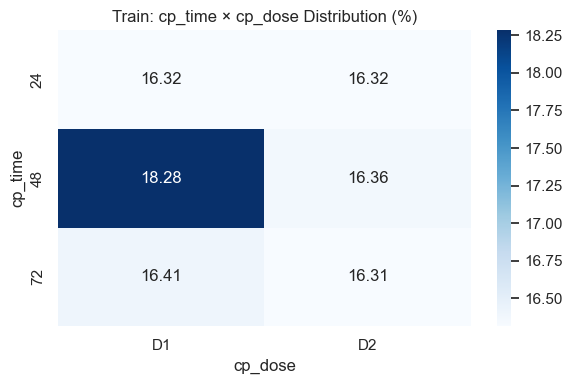

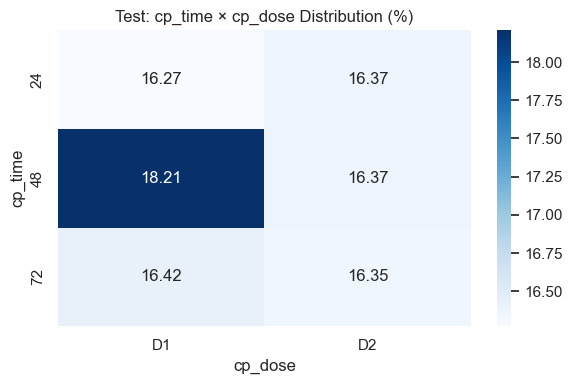

In [10]:
def plot_time_dose_heatmap(df, title):
    heatmap_data = (
        df
        .groupby(["cp_time", "cp_dose"])
        .size()
        .reset_index(name="count")
    )
    
    heatmap_data["percent"] = heatmap_data["count"] / len(df) * 100
    
    heatmap_pivot = heatmap_data.pivot(
        index="cp_time",
        columns="cp_dose",
        values="percent"
    )
    
    plt.figure(figsize=(6, 4))
    sns.heatmap(
        heatmap_pivot,
        annot=True,
        fmt=".2f",
        cmap="Blues"
    )
    plt.title(title)
    plt.xlabel("cp_dose")
    plt.ylabel("cp_time")
    plt.tight_layout()
    plt.show()


plot_time_dose_heatmap(train_features, "Train: cp_time × cp_dose Distribution (%)")
plot_time_dose_heatmap(test_features, "Test: cp_time × cp_dose Distribution (%)")

### 2.6 Metadata Interaction Insights and Decisions

The metadata interaction analysis shows that the experimental design is mostly balanced between train and test.

The `cp_time × cp_dose` heatmaps are especially useful because treatment duration and dose may jointly affect biological response. Both train and test show very similar time-dose patterns. The `48 × D1` group is slightly larger than the other time-dose combinations, but this pattern appears in both train and test, so it does not indicate a serious train-test shift.

The `cp_type × cp_time` and `cp_type × cp_dose` combinations also show the expected structure. Control samples are a small portion of the dataset and are distributed across time and dose conditions. Test data has slightly more control samples than train data, but the difference is small.

Main conclusions:

- Metadata combinations are consistent between train and test.
- There is no strong experimental-design distribution shift.
- `cp_time × cp_dose` may be useful as an interaction feature.
- `cp_type` should be kept because it separates treated and control samples.
- Control samples should be handled carefully during final prediction because they have no active MoA targets.

## 3. Scored Target Behavior and Multi-Label Structure

The scored target matrix contains the main MoA labels that the model must predict.

Each column represents one scored MoA target, and each row represents one sample.

This is a multi-label classification problem because a sample can have zero, one, or multiple active target labels.

In this section, we analyze:

- target sparsity,
- target imbalance,
- target frequency,
- sample-level multi-label behavior,
- and how target activity changes under experimental conditions.

The goal is to convert target analysis into useful modeling and feature engineering decisions.

### 3.1 Target Matrix Sparsity Overview

Before analyzing individual targets, we first examine the full scored target matrix.

This helps us understand the overall label structure:

- how many samples exist,
- how many scored targets exist,
- how many total label entries exist,
- how many labels are positive,
- how many labels are negative,
- and how sparse the target matrix is.

This is important because sparse multi-label targets require probability-based models and careful validation.

In [11]:
scored_target_features

['5-alpha_reductase_inhibitor',
 '11-beta-hsd1_inhibitor',
 'acat_inhibitor',
 'acetylcholine_receptor_agonist',
 'acetylcholine_receptor_antagonist',
 'acetylcholinesterase_inhibitor',
 'adenosine_receptor_agonist',
 'adenosine_receptor_antagonist',
 'adenylyl_cyclase_activator',
 'adrenergic_receptor_agonist',
 'adrenergic_receptor_antagonist',
 'akt_inhibitor',
 'aldehyde_dehydrogenase_inhibitor',
 'alk_inhibitor',
 'ampk_activator',
 'analgesic',
 'androgen_receptor_agonist',
 'androgen_receptor_antagonist',
 'anesthetic_-_local',
 'angiogenesis_inhibitor',
 'angiotensin_receptor_antagonist',
 'anti-inflammatory',
 'antiarrhythmic',
 'antibiotic',
 'anticonvulsant',
 'antifungal',
 'antihistamine',
 'antimalarial',
 'antioxidant',
 'antiprotozoal',
 'antiviral',
 'apoptosis_stimulant',
 'aromatase_inhibitor',
 'atm_kinase_inhibitor',
 'atp-sensitive_potassium_channel_antagonist',
 'atp_synthase_inhibitor',
 'atpase_inhibitor',
 'atr_kinase_inhibitor',
 'aurora_kinase_inhibitor',
 '

In [12]:
# Create the scored target matrix without sig_id
y_scored_matrix = y_scored[scored_target_features].copy()

n_samples = y_scored_matrix.shape[0]
n_targets = y_scored_matrix.shape[1]

total_label_entries = n_samples * n_targets
total_positive_labels = int(y_scored_matrix.values.sum())
total_negative_labels = int(total_label_entries - total_positive_labels)

positive_label_percentage = total_positive_labels / total_label_entries * 100
negative_label_percentage = total_negative_labels / total_label_entries * 100
sparsity_percentage = negative_label_percentage

target_matrix_summary = pd.DataFrame({
    "metric": [
        "Number of samples",
        "Number of scored targets",
        "Total label entries",
        "Total positive labels",
        "Total negative labels",
        "Positive label percentage",
        "Sparsity percentage"
    ],
    "value": [
        n_samples,
        n_targets,
        total_label_entries,
        total_positive_labels,
        total_negative_labels,
        round(positive_label_percentage, 4),
        round(sparsity_percentage, 4)
    ]
})

target_matrix_summary

,metric,value
0,Number of samples,2.381400e+04
1,Number of scored targets,2.060000e+02
2,Total label entries,4.905684e+06
3,Total positive labels,1.684400e+04
4,Total negative labels,4.888840e+06
5,Positive label percentage,3.434000e-01
6,Sparsity percentage,9.965660e+01


### 3.1.2 Positive vs Negative Label Balance

Now we visualize the proportion of positive and negative target labels.

Because the target matrix is expected to be highly sparse, this plot helps show the imbalance clearly.

We use percentages instead of raw counts so the imbalance is easier to interpret.

In [13]:
target_balance_table = pd.DataFrame({
    "label_type": ["Positive labels", "Negative labels"],
    "count": [total_positive_labels, total_negative_labels],
    "percentage": [positive_label_percentage, negative_label_percentage]
})

target_balance_table

,label_type,count,percentage
0,Positive labels,16844,0.343357
1,Negative labels,4888840,99.656643


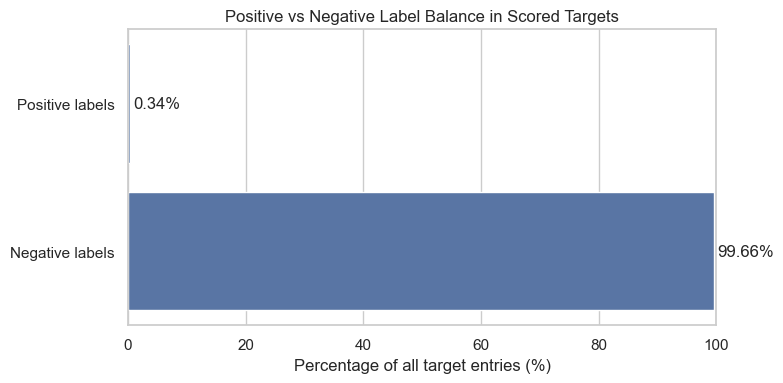

In [14]:
plt.figure(figsize=(8, 4))

sns.barplot(
    data=target_balance_table,
    x="percentage",
    y="label_type"
)

plt.title("Positive vs Negative Label Balance in Scored Targets")
plt.xlabel("Percentage of all target entries (%)")
plt.ylabel("")
plt.xlim(0, 100)

for index, row in target_balance_table.iterrows():
    plt.text(
        row["percentage"] + 0.5,
        index,
        f'{row["percentage"]:.2f}%',
        va="center"
    )

plt.tight_layout()
plt.savefig(FIGURE_DIR / "section_3_1_target_label_balance.png", dpi=300, bbox_inches="tight")
plt.show()

### 3.1.3 Initial Modeling Implications

The scored target matrix is extremely sparse.

Only **0.3434%** of all target entries are positive, while **99.6566%** are negative. This means most MoA targets are inactive for most samples.

This has important modeling implications:

- simple accuracy is not useful because a model could predict mostly zeros and still look good,
- the model must predict probabilities for each target, not only hard class labels,
- rare positive labels will be difficult to learn,
- validation must preserve multi-label structure as much as possible,
- probability calibration and prediction clipping may be important during final modeling,
- neural networks should use sigmoid outputs, not softmax, because multiple targets can be active at the same time.

This confirms that the project should be treated as a sparse multi-label classification problem.

In [15]:
target_matrix_implication_table = pd.DataFrame({
    "finding": [
        "The scored target matrix contains 206 target labels",
        "Only 0.3434% of all target entries are positive",
        "99.6566% of all target entries are negative",
        "The target matrix is extremely sparse",
        "This is a multi-label classification problem"
    ],
    "evidence_from_output": [
        "There are 206 scored target columns",
        "Total positive labels = 16,844 out of 4,905,684 entries",
        "Total negative labels = 4,888,840 out of 4,905,684 entries",
        "Most target values are zero",
        "Each sample can have zero, one, or multiple active MoA labels"
    ],
    "modeling_decision": [
        "Use multi-output / multi-label modeling",
        "Do not use accuracy as the main metric",
        "Use probability-based metrics such as log loss",
        "Use careful validation and monitor rare targets later",
        "Use sigmoid outputs for neural networks, not softmax"
    ]
})

target_matrix_implication_table

,finding,evidence_from_output,modeling_decision
0,The scored target matrix contains 206 target l...,There are 206 scored target columns,Use multi-output / multi-label modeling
1,Only 0.3434% of all target entries are positive,"Total positive labels = 16,844 out of 4,905,68...",Do not use accuracy as the main metric
2,99.6566% of all target entries are negative,"Total negative labels = 4,888,840 out of 4,905...",Use probability-based metrics such as log loss
3,The target matrix is extremely sparse,Most target values are zero,Use careful validation and monitor rare target...
4,This is a multi-label classification problem,"Each sample can have zero, one, or multiple ac...","Use sigmoid outputs for neural networks, not s..."


### 3.2 Target Frequency and Imbalance Analysis

After understanding the overall sparsity of the scored target matrix, we now analyze target-level imbalance.

Each scored target column represents one MoA label. Some targets may appear frequently, while others may appear only a few times.

This section helps us identify:

- frequent targets,
- rare targets,
- target frequency distribution,
- and target groups based on positive sample count.

This is important because rare targets are harder to learn and may require careful validation and target-wise error analysis later.

#### 3.2.1 Positive Count per Target

First, we calculate how many positive samples exist for each of the 206 scored targets.

This gives us a target-level frequency table, which will be used for imbalance analysis.

In [16]:
target_frequency_table = pd.DataFrame({
    "target": scored_target_features,
    "positive_count": y_scored_matrix.sum(axis=0).values
})

target_frequency_table["negative_count"] = n_samples - target_frequency_table["positive_count"]
target_frequency_table["positive_percentage"] = (
    target_frequency_table["positive_count"] / n_samples * 100
)

target_frequency_table = target_frequency_table.sort_values(
    by="positive_count",
    ascending=False
).reset_index(drop=True)

target_frequency_table

,target,positive_count,negative_count,positive_percentage
0,nfkb_inhibitor,832,22982,3.493743
1,proteasome_inhibitor,726,23088,3.048627
2,cyclooxygenase_inhibitor,435,23379,1.826657
3,dopamine_receptor_antagonist,424,23390,1.780465
4,serotonin_receptor_antagonist,404,23410,1.696481
...,...,...,...,...
201,protein_phosphatase_inhibitor,6,23808,0.025195
202,ubiquitin_specific_protease_inhibitor,6,23808,0.025195
203,steroid,6,23808,0.025195
204,atp-sensitive_potassium_channel_antagonist,1,23813,0.004199


#### 3.2.2 Target Frequency Summary

Now we summarize the distribution of positive counts across all scored targets.

This tells us whether most targets are rare or whether positive samples are evenly distributed across targets.

In [17]:
target_frequency_summary = target_frequency_table["positive_count"].describe().to_frame(
    name="positive_count_summary"
)

target_frequency_summary

,positive_count_summary
count,206.000000
mean,81.766990
std,115.160351
min,1.000000
25%,19.000000
50%,38.500000
75%,83.000000
max,832.000000


#### 3.2.3 Distribution of Target Positive Counts

This plot shows how positive samples are distributed across the 206 scored targets.

A right-skewed distribution means that only a few targets are frequent, while many targets are rare.

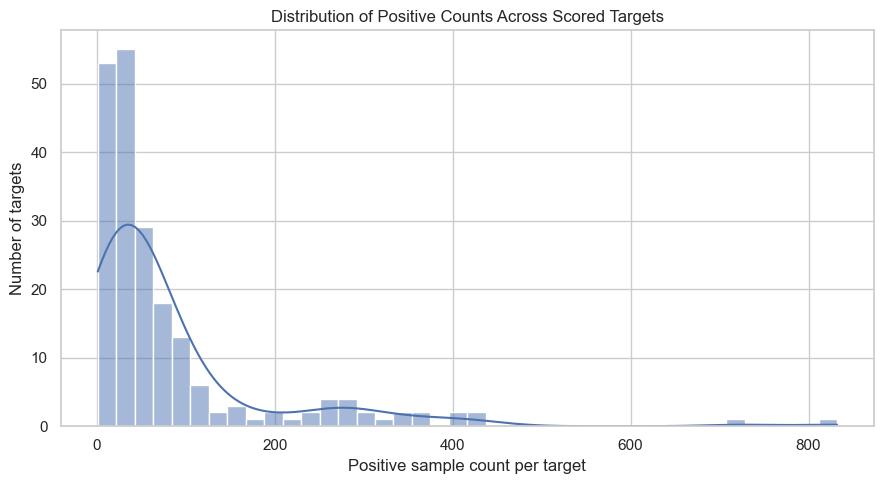

In [18]:
plt.figure(figsize=(9, 5))

sns.histplot(
    data=target_frequency_table,
    x="positive_count",
    bins=40,
    kde=True
)

plt.title("Distribution of Positive Counts Across Scored Targets")
plt.xlabel("Positive sample count per target")
plt.ylabel("Number of targets")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "section_3_2_target_positive_count_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

#### 3.2.4 Top 30 Most Frequent Targets

Now we visualize the most frequent scored targets.

Frequent targets usually have more training examples and may be easier for models to learn compared with rare targets.

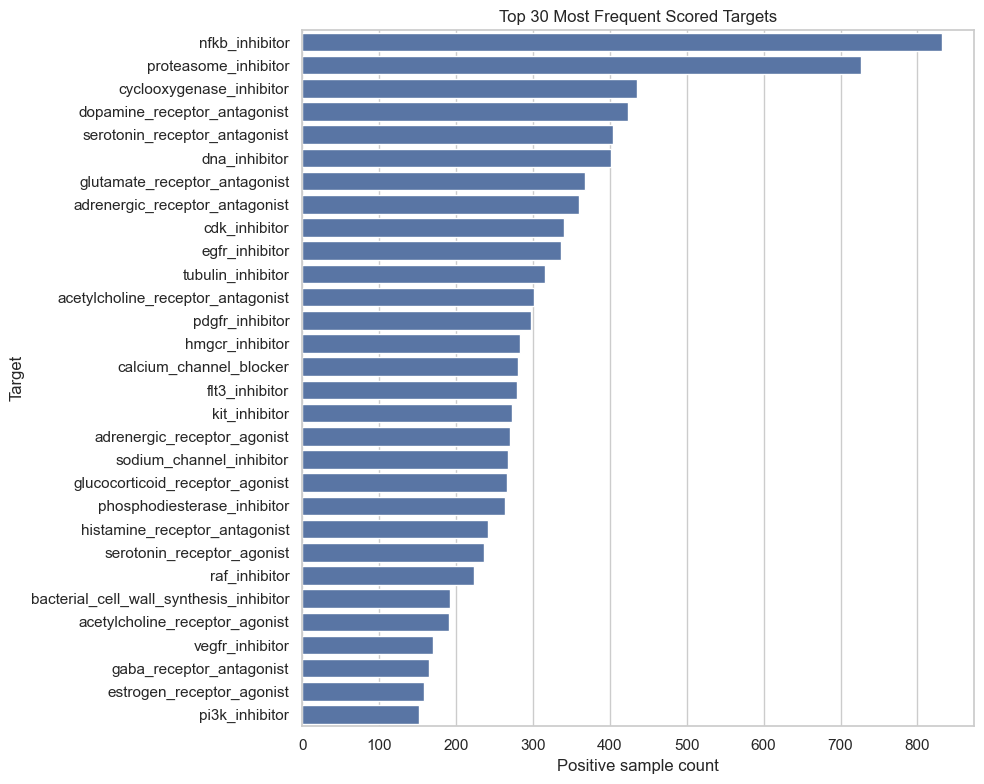

In [19]:
top_30_targets = target_frequency_table.head(30).copy()

plt.figure(figsize=(10, 8))

sns.barplot(
    data=top_30_targets,
    x="positive_count",
    y="target"
)

plt.title("Top 30 Most Frequent Scored Targets")
plt.xlabel("Positive sample count")
plt.ylabel("Target")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "section_3_2_top_30_frequent_targets.png", dpi=300, bbox_inches="tight")
plt.show()

#### 3.2.5 Rarest Targets

Now we inspect the rarest scored targets.

Rare targets have very few positive examples, which can make them difficult for the model to learn reliably.

In [20]:
rarest_20_targets = target_frequency_table.tail(20).sort_values(
    by="positive_count",
    ascending=True
).reset_index(drop=True)

rarest_20_targets

,target,positive_count,negative_count,positive_percentage
0,atp-sensitive_potassium_channel_antagonist,1,23813,0.004199
1,erbb2_inhibitor,1,23813,0.004199
2,atm_kinase_inhibitor,6,23808,0.025195
3,autotaxin_inhibitor,6,23808,0.025195
4,calcineurin_inhibitor,6,23808,0.025195
5,coagulation_factor_inhibitor,6,23808,0.025195
6,diuretic,6,23808,0.025195
7,retinoid_receptor_antagonist,6,23808,0.025195
8,tropomyosin_receptor_kinase_inhibitor,6,23808,0.025195
9,nicotinic_receptor_agonist,6,23808,0.025195


#### 3.2.6 Target Frequency Groups

To make target imbalance easier to understand, we group targets by positive sample count.

This helps us estimate how many targets are very rare, rare, medium-frequency, or frequent.

In [21]:
def assign_target_frequency_group(positive_count):
    if positive_count < 10:
        return "Very rare (<10)"
    elif positive_count < 50:
        return "Rare (10-49)"
    elif positive_count < 200:
        return "Medium (50-199)"
    else:
        return "Frequent (>=200)"


target_frequency_table["frequency_group"] = target_frequency_table["positive_count"].apply(
    assign_target_frequency_group
)

target_frequency_group_summary = (
    target_frequency_table
    .groupby("frequency_group")
    .agg(
        number_of_targets=("target", "count"),
        min_positive_count=("positive_count", "min"),
        median_positive_count=("positive_count", "median"),
        max_positive_count=("positive_count", "max")
    )
    .reset_index()
)

frequency_group_order = [
    "Very rare (<10)",
    "Rare (10-49)",
    "Medium (50-199)",
    "Frequent (>=200)"
]

target_frequency_group_summary["frequency_group"] = pd.Categorical(
    target_frequency_group_summary["frequency_group"],
    categories=frequency_group_order,
    ordered=True
)

target_frequency_group_summary = target_frequency_group_summary.sort_values(
    "frequency_group"
).reset_index(drop=True)

target_frequency_group_summary

,frequency_group,number_of_targets,min_positive_count,median_positive_count,max_positive_count
0,Very rare (<10),22,1,6.0,7
1,Rare (10-49),97,12,26.0,49
2,Medium (50-199),63,50,74.0,192
3,Frequent (>=200),24,223,299.0,832


#### 3.2.7 Visualize Target Frequency Groups

This plot summarizes target imbalance at a higher level.

Instead of looking at 206 targets one by one, we can see how many targets belong to each frequency group.

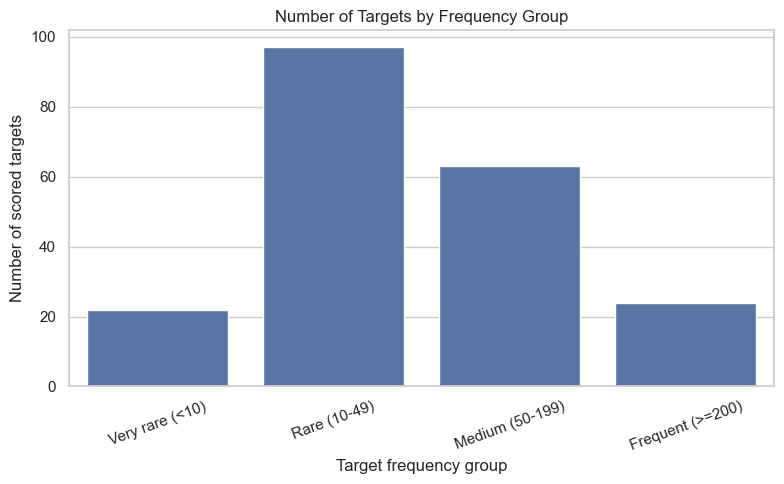

In [22]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=target_frequency_group_summary,
    x="frequency_group",
    y="number_of_targets"
)

plt.title("Number of Targets by Frequency Group")
plt.xlabel("Target frequency group")
plt.ylabel("Number of scored targets")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "section_3_2_target_frequency_groups.png", dpi=300, bbox_inches="tight")
plt.show()

#### 3.2.8 Target Frequency Insights

The target frequency analysis shows strong imbalance across the 206 scored MoA labels.

Most targets have relatively low positive sample counts, while only a small number of targets have many positive examples. The distribution is clearly right-skewed: many targets are concentrated in the low-frequency range, and only a few targets appear very frequently.

The top frequent targets, such as `nfkb_inhibitor` and `proteasome_inhibitor`, have substantially more positive samples than most other targets. This means these labels may be easier for models to learn compared with rare labels.

The frequency group plot also shows that many targets belong to rare or medium-frequency groups, while only a smaller portion of targets are highly frequent. This confirms that target imbalance is not only a global sparsity issue, but also a target-level imbalance issue.

Key implications:

- rare targets may be difficult to learn because they have limited positive examples,
- frequent targets may dominate the model's learning signal,
- model evaluation should include target-wise error analysis later,
- validation should preserve multi-label structure as much as possible,
- rare targets should not be removed because they are part of the official scored prediction task.

### 3.3 Sample-Level Multi-Label Behavior

After analyzing target-level frequency, we now analyze the labels from a sample-level perspective.

For each sample, we count how many scored MoA targets are active.

This helps us understand:

- how many samples have no active scored target,
- how many samples have exactly one active target,
- how many samples have multiple active targets,
- and the maximum number of active targets in one sample.

This section is important because it confirms that the problem is multi-label, not multiclass.

#### 3.3.1 Active Target Count per Sample

For each sample, we calculate the number of active scored targets.

This new temporary column is called `active_target_count`.

It is used only for EDA and will not be used directly as a model feature.

In [23]:
sample_target_activity = pd.DataFrame({
    ID_COL: y_scored[ID_COL],
    "active_target_count": y_scored_matrix.sum(axis=1)
})

sample_target_activity

,sig_id,active_target_count
0,id_000644bb2,1
1,id_000779bfc,0
2,id_000a6266a,3
3,id_0015fd391,0
4,id_001626bd3,1
...,...,...
23809,id_fffb1ceed,1
23810,id_fffb70c0c,1
23811,id_fffc1c3f4,0
23812,id_fffcb9e7c,1


#### 3.3.2 Active Target Count Distribution

Now we summarize how many samples have 0, 1, 2, or more active scored targets.

This helps us understand the sample-level multi-label structure of the dataset.

In [24]:
active_target_count_distribution = (
    sample_target_activity["active_target_count"]
    .value_counts()
    .sort_index()
    .reset_index()
)

active_target_count_distribution.columns = [
    "active_target_count",
    "sample_count"
]

active_target_count_distribution["sample_percentage"] = (
    active_target_count_distribution["sample_count"] / n_samples * 100
)

active_target_count_distribution

,active_target_count,sample_count,sample_percentage
0,0,9367,39.334005
1,1,12532,52.624507
2,2,1538,6.458386
3,3,303,1.272361
4,4,55,0.230957
5,5,13,0.054590
6,7,6,0.025195


#### 3.3.3 Visualize Active Target Count per Sample

This plot shows the distribution of active scored targets per sample.

It helps us visually confirm whether most samples have zero labels, one label, or multiple labels.

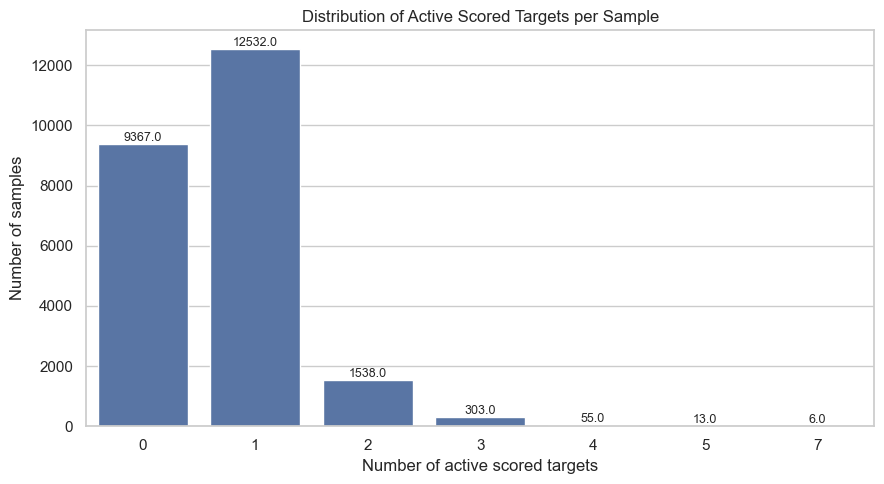

In [25]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=active_target_count_distribution,
    x="active_target_count",
    y="sample_count"
)

plt.title("Distribution of Active Scored Targets per Sample")
plt.xlabel("Number of active scored targets")
plt.ylabel("Number of samples")

for index, row in active_target_count_distribution.iterrows():
    plt.text(
        index,
        row["sample_count"],
        f'{row["sample_count"]}',
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()
plt.savefig(FIGURE_DIR / "section_3_3_active_targets_per_sample.png", dpi=300, bbox_inches="tight")
plt.show()

#### 3.3.4 Zero-Label, Single-Label, and Multi-Label Summary

To make the sample-level label structure easier to interpret, we group samples into three categories:

- zero-label samples: no active scored target,
- single-label samples: exactly one active scored target,
- multi-label samples: more than one active scored target.

This summary clearly shows why the task requires multi-label modeling.

In [26]:
zero_label_count = int((sample_target_activity["active_target_count"] == 0).sum())
single_label_count = int((sample_target_activity["active_target_count"] == 1).sum())
multi_label_count = int((sample_target_activity["active_target_count"] > 1).sum())

sample_label_type_summary = pd.DataFrame({
    "sample_label_type": [
        "Zero-label samples",
        "Single-label samples",
        "Multi-label samples"
    ],
    "sample_count": [
        zero_label_count,
        single_label_count,
        multi_label_count
    ]
})

sample_label_type_summary["sample_percentage"] = (
    sample_label_type_summary["sample_count"] / n_samples * 100
)

sample_label_type_summary

,sample_label_type,sample_count,sample_percentage
0,Zero-label samples,9367,39.334005
1,Single-label samples,12532,52.624507
2,Multi-label samples,1915,8.041488


#### 3.3.5 Sample-Level Label Cardinality Summary

Now we calculate several compact statistics for sample-level label cardinality.

This helps summarize the multi-label structure in one place.

In [27]:
sample_label_cardinality_summary = {
    "total_samples": int(n_samples),
    "zero_label_samples": zero_label_count,
    "single_label_samples": single_label_count,
    "multi_label_samples": multi_label_count,
    "zero_label_percentage": round(zero_label_count / n_samples * 100, 4),
    "single_label_percentage": round(single_label_count / n_samples * 100, 4),
    "multi_label_percentage": round(multi_label_count / n_samples * 100, 4),
    "mean_active_targets_per_sample": round(sample_target_activity["active_target_count"].mean(), 4),
    "median_active_targets_per_sample": round(sample_target_activity["active_target_count"].median(), 4),
    "max_active_targets_in_one_sample": int(sample_target_activity["active_target_count"].max()),
}

sample_label_cardinality_summary

{'total_samples': 23814,
 'zero_label_samples': 9367,
 'single_label_samples': 12532,
 'multi_label_samples': 1915,
 'zero_label_percentage': 39.334,
 'single_label_percentage': 52.6245,
 'multi_label_percentage': 8.0415,
 'mean_active_targets_per_sample': np.float64(0.7073),
 'median_active_targets_per_sample': np.float64(1.0),
 'max_active_targets_in_one_sample': 7}

#### 3.3.6 Multi-Label Modeling Implications

The sample-level target analysis confirms that this is a multi-label classification problem.

Out of 23,814 training samples:

- 9,367 samples have no active scored target.
- 12,532 samples have exactly one active scored target.
- 1,915 samples have more than one active scored target.

This means 39.3340% of samples are zero-label samples, 52.6245% are single-label samples, and 8.0415% are true multi-label samples.

The average number of active scored targets per sample is only 0.7073, while the maximum number of active scored targets in one sample is 7. This shows that the target matrix is sparse not only at the target-entry level, but also at the sample level.

Modeling implications:

- zero-label samples are valid and should not be removed,
- the model should not be trained as a multiclass classifier,
- softmax output is not appropriate because targets are not mutually exclusive,
- neural networks should use one sigmoid output per target,
- classical models should use multi-output or one-vs-rest style training,
- validation should preserve the multi-label structure as much as possible.

In [28]:
sample_label_insight_table = pd.DataFrame({
    "finding": [
        "A large portion of samples have no active scored target",
        "Most labeled samples have exactly one active scored target",
        "A smaller but important group has multiple active targets",
        "The average active target count per sample is below 1",
        "Some samples have up to 7 active scored targets",
        "The task is multi-label, not multiclass"
    ],
    "evidence_from_eda": [
        "9,367 samples, or 39.3340%, have active_target_count = 0",
        "12,532 samples, or 52.6245%, have active_target_count = 1",
        "1,915 samples, or 8.0415%, have active_target_count > 1",
        "Mean active targets per sample = 0.7073",
        "Maximum active targets in one sample = 7",
        "Samples can have zero, one, or multiple active labels"
    ],
    "modeling_decision": [
        "Keep zero-label samples during training",
        "Use binary target columns instead of a single class label",
        "Use multi-label models that predict one probability per target",
        "Expect strong sparsity at the sample level",
        "Use sigmoid outputs instead of softmax for neural networks",
        "Use probability-based multi-label evaluation such as log loss"
    ]
})

sample_label_insight_table

,finding,evidence_from_eda,modeling_decision
0,A large portion of samples have no active scor...,"9,367 samples, or 39.3340%, have active_target...",Keep zero-label samples during training
1,Most labeled samples have exactly one active s...,"12,532 samples, or 52.6245%, have active_targe...",Use binary target columns instead of a single ...
2,A smaller but important group has multiple act...,"1,915 samples, or 8.0415%, have active_target_...",Use multi-label models that predict one probab...
3,The average active target count per sample is ...,Mean active targets per sample = 0.7073,Expect strong sparsity at the sample level
4,Some samples have up to 7 active scored targets,Maximum active targets in one sample = 7,Use sigmoid outputs instead of softmax for neu...
5,"The task is multi-label, not multiclass","Samples can have zero, one, or multiple active...",Use probability-based multi-label evaluation s...


### 3.4 Target Activity under Experimental Conditions

In the previous sections, we analyzed target sparsity, target frequency imbalance, and sample-level multi-label behavior.

Now we examine whether target activity changes under different experimental conditions.

We analyze target activity using:

- `cp_type`: treatment type,
- `cp_time`: treatment duration,
- `cp_dose`: treatment dose,
- `cp_time × cp_dose`: time-dose interaction.

For `cp_time`, `cp_dose`, and `cp_time × cp_dose`, we focus mainly on treated samples (`trt_cp`) because control samples have no active MoA targets and can dilute the treatment-specific signal.

This section helps decide whether metadata and interaction features should be used during feature engineering.

#### 3.4.1 Create Target Activity Metadata Table

First, we combine metadata columns with the sample-level active target count.

This creates a temporary EDA table that allows us to compare target activity across experimental conditions.

This table is only for analysis. The `active_target_count` column is derived from the target labels and must not be used as an input feature during model training.

In [29]:
target_activity_metadata = train_features[
    [ID_COL, "cp_type", "cp_time", "cp_dose"]
].merge(
    sample_target_activity,
    on=ID_COL,
    how="left",
    validate="one_to_one"
)

target_activity_metadata.head()

,sig_id,cp_type,cp_time,cp_dose,active_target_count
0,id_000644bb2,trt_cp,24,D1,1
1,id_000779bfc,trt_cp,72,D1,0
2,id_000a6266a,trt_cp,48,D1,3
3,id_0015fd391,trt_cp,48,D1,0
4,id_001626bd3,trt_cp,72,D2,1


In [30]:
target_activity_metadata_check = {
    "rows": target_activity_metadata.shape[0],
    "columns": target_activity_metadata.shape[1],
    "missing_active_target_count": int(target_activity_metadata["active_target_count"].isna().sum()),
    "min_active_target_count": int(target_activity_metadata["active_target_count"].min()),
    "max_active_target_count": int(target_activity_metadata["active_target_count"].max()),
}

target_activity_metadata_check

{'rows': 23814,
 'columns': 5,
 'missing_active_target_count': 0,
 'min_active_target_count': 0,
 'max_active_target_count': 7}

#### 3.4.2 Target Activity by `cp_type`

Now we compare target activity between control samples and treated compound samples.

This is important because control samples are expected to have zero active scored targets.

If this pattern holds, it supports using control-sample post-processing later during final prediction.

In [31]:
cp_type_target_activity = (
    target_activity_metadata
    .groupby("cp_type")
    .agg(
        sample_count=(ID_COL, "count"),
        total_active_targets=("active_target_count", "sum"),
        mean_active_targets=("active_target_count", "mean"),
        median_active_targets=("active_target_count", "median"),
        max_active_targets=("active_target_count", "max")
    )
    .reset_index()
)

cp_type_target_activity

,cp_type,sample_count,total_active_targets,mean_active_targets,median_active_targets,max_active_targets
0,ctl_vehicle,1866,0,0.00000,0.0,0
1,trt_cp,21948,16844,0.76745,1.0,7


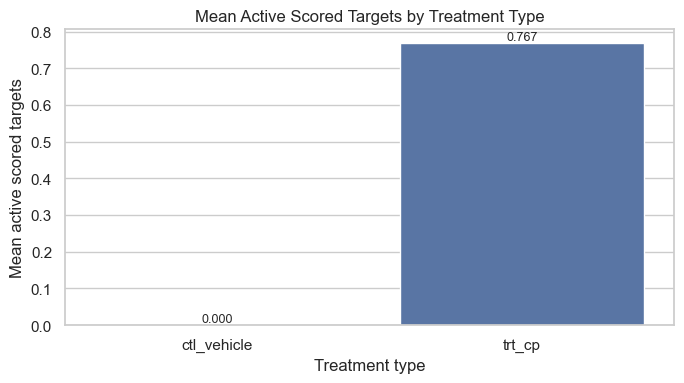

In [32]:
plt.figure(figsize=(7, 4))

sns.barplot(
    data=cp_type_target_activity,
    x="cp_type",
    y="mean_active_targets"
)

plt.title("Mean Active Scored Targets by Treatment Type")
plt.xlabel("Treatment type")
plt.ylabel("Mean active scored targets")

for index, row in cp_type_target_activity.iterrows():
    plt.text(
        index,
        row["mean_active_targets"],
        f'{row["mean_active_targets"]:.3f}',
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()
plt.savefig(FIGURE_DIR / "section_3_4_target_activity_by_cp_type.png", dpi=300, bbox_inches="tight")
plt.show()

#### 3.4.3 Target Activity by `cp_time` and `cp_dose`

Next, we analyze target activity by treatment duration and treatment dose.

For this analysis, we focus on treated samples only (`cp_type == "trt_cp"`). This avoids mixing control samples, which have zero active targets by design.

This helps us check whether time and dose are related to the number of active MoA labels.

In [33]:
treated_target_activity = target_activity_metadata[
    target_activity_metadata["cp_type"] == "trt_cp"
].copy()

treated_target_activity.shape

(21948, 5)

In [34]:
def summarize_target_activity_by_group(df, group_col):
    summary = (
        df
        .groupby(group_col)
        .agg(
            sample_count=(ID_COL, "count"),
            mean_active_targets=("active_target_count", "mean"),
            median_active_targets=("active_target_count", "median"),
            max_active_targets=("active_target_count", "max")
        )
        .reset_index()
    )
    
    return summary


cp_time_target_activity = summarize_target_activity_by_group(
    treated_target_activity,
    "cp_time"
)

cp_dose_target_activity = summarize_target_activity_by_group(
    treated_target_activity,
    "cp_dose"
)

display(cp_time_target_activity)
display(cp_dose_target_activity)

,cp_time,sample_count,mean_active_targets,median_active_targets,max_active_targets
0,24,7166,0.766816,1.0,7
1,48,7602,0.766772,1.0,7
2,72,7180,0.768802,1.0,7


,cp_dose,sample_count,mean_active_targets,median_active_targets,max_active_targets
0,D1,11196,0.768221,1.0,7
1,D2,10752,0.766648,1.0,7


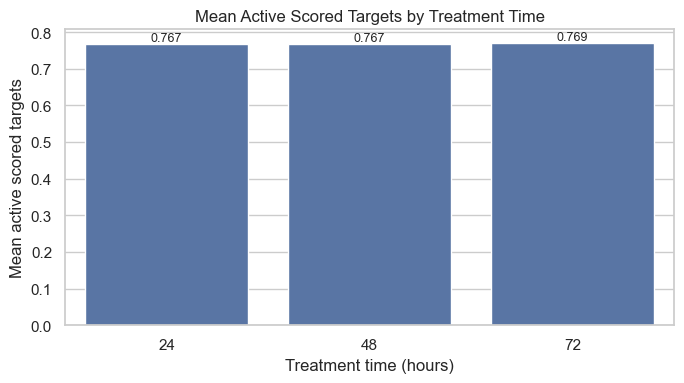

In [35]:
plt.figure(figsize=(7, 4))

sns.barplot(
    data=cp_time_target_activity,
    x="cp_time",
    y="mean_active_targets"
)

plt.title("Mean Active Scored Targets by Treatment Time")
plt.xlabel("Treatment time (hours)")
plt.ylabel("Mean active scored targets")

for index, row in cp_time_target_activity.iterrows():
    plt.text(
        index,
        row["mean_active_targets"],
        f'{row["mean_active_targets"]:.3f}',
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()
plt.savefig(FIGURE_DIR / "section_3_4_target_activity_by_cp_time.png", dpi=300, bbox_inches="tight")
plt.show()

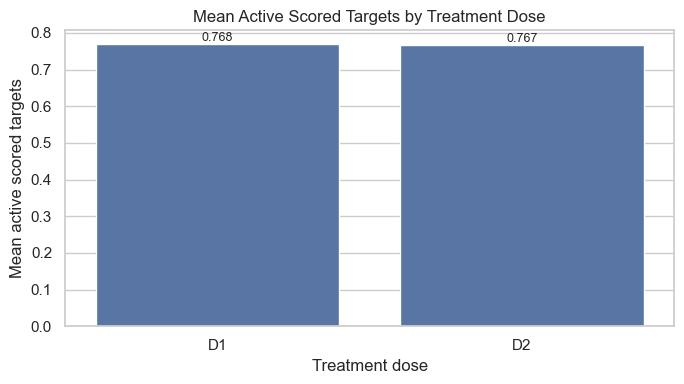

In [36]:
plt.figure(figsize=(7, 4))

sns.barplot(
    data=cp_dose_target_activity,
    x="cp_dose",
    y="mean_active_targets"
)

plt.title("Mean Active Scored Targets by Treatment Dose")
plt.xlabel("Treatment dose")
plt.ylabel("Mean active scored targets")

for index, row in cp_dose_target_activity.iterrows():
    plt.text(
        index,
        row["mean_active_targets"],
        f'{row["mean_active_targets"]:.3f}',
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()
plt.savefig(FIGURE_DIR / "section_3_4_target_activity_by_cp_dose.png", dpi=300, bbox_inches="tight")
plt.show()

#### 3.4.4 Target Activity by `cp_time × cp_dose`

Now we analyze the interaction between treatment time and dose.

This is useful because dose effects may depend on treatment duration.

If target activity differs across time-dose combinations, then a `cp_time × cp_dose` interaction feature may be useful in feature engineering.

In [37]:
time_dose_target_activity = (
    treated_target_activity
    .groupby(["cp_time", "cp_dose"])
    .agg(
        sample_count=(ID_COL, "count"),
        mean_active_targets=("active_target_count", "mean"),
        median_active_targets=("active_target_count", "median"),
        max_active_targets=("active_target_count", "max")
    )
    .reset_index()
)

time_dose_target_activity

,cp_time,cp_dose,sample_count,mean_active_targets,median_active_targets,max_active_targets
0,24,D1,3585,0.768201,1.0,7
1,24,D2,3581,0.765429,1.0,7
2,48,D1,4011,0.765894,1.0,7
3,48,D2,3591,0.767753,1.0,7
4,72,D1,3600,0.770833,1.0,7
5,72,D2,3580,0.766760,1.0,7


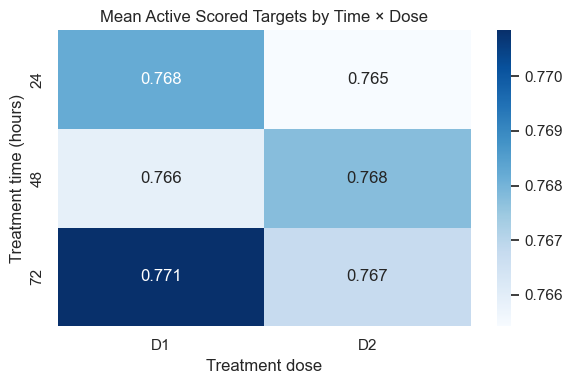

In [38]:
time_dose_activity_pivot = time_dose_target_activity.pivot(
    index="cp_time",
    columns="cp_dose",
    values="mean_active_targets"
)

plt.figure(figsize=(6, 4))

sns.heatmap(
    time_dose_activity_pivot,
    annot=True,
    fmt=".3f",
    cmap="Blues"
)

plt.title("Mean Active Scored Targets by Time × Dose")
plt.xlabel("Treatment dose")
plt.ylabel("Treatment time (hours)")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "section_3_4_target_activity_time_dose_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

#### 3.4.5 Target Activity under Experimental Conditions: Insights

The target activity analysis shows that `cp_type` is the strongest metadata signal for scored target activity.

Control samples (`ctl_vehicle`) have a mean active target count of **0.000**, while treated compound samples (`trt_cp`) have a mean active target count of about **0.767**. This confirms the expected structural behavior of the dataset: control samples do not have active scored MoA targets.

For treated samples, target activity is very stable across treatment time and dose. The mean active target count is almost identical across `cp_time` values:

- 24 hours: about **0.767**
- 48 hours: about **0.767**
- 72 hours: about **0.769**

Similarly, target activity is nearly identical between dose groups:

- D1: about **0.768**
- D2: about **0.767**

The `cp_time × cp_dose` heatmap also shows only very small differences, with all groups staying close to **0.765–0.771**. This suggests that time and dose do not strongly change the average number of active scored targets.

Key conclusions:

- `cp_type` is essential because it separates control and treated samples.
- `ctl_vehicle` rows should be post-processed to zero predictions in the final submission.
- `cp_time` and `cp_dose` should still be kept as model features because they may affect the gene and cell response patterns, even if the average target count is similar.
- The `cp_time × cp_dose` interaction can be tested during feature engineering, but current target-count evidence suggests it may provide only limited direct signal.
- We should not over-interpret the small differences between time and dose groups.

In [39]:
metadata_target_activity_insight_table = pd.DataFrame({
    "finding": [
        "cp_type is strongly related to target activity",
        "Control samples have no active scored targets",
        "Treated samples show nonzero target activity",
        "Target activity is very stable across cp_time",
        "Target activity is very stable across cp_dose",
        "cp_time × cp_dose shows only tiny differences"
    ],
    "evidence_from_eda": [
        "ctl_vehicle mean active targets = 0.000, trt_cp mean active targets ≈ 0.767",
        "The cp_type plot shows zero mean target activity for ctl_vehicle",
        "trt_cp samples have mean active target count around 0.767",
        "24h, 48h, and 72h all have mean active target counts around 0.767–0.769",
        "D1 and D2 both have mean active target counts around 0.767–0.768",
        "All time-dose combinations are close to 0.765–0.771"
    ],
    "feature_engineering_or_modeling_decision": [
        "Keep cp_type as an important metadata feature",
        "Apply control-sample post-processing during final prediction",
        "Use treated samples for treatment-specific biological analysis",
        "Keep cp_time, but do not expect it alone to strongly explain label count",
        "Keep cp_dose, but do not expect it alone to strongly explain label count",
        "Test cp_time × cp_dose interaction later, but treat it as optional"
    ]
})

metadata_target_activity_insight_table

,finding,evidence_from_eda,feature_engineering_or_modeling_decision
0,cp_type is strongly related to target activity,"ctl_vehicle mean active targets = 0.000, trt_c...",Keep cp_type as an important metadata feature
1,Control samples have no active scored targets,The cp_type plot shows zero mean target activi...,Apply control-sample post-processing during fi...
2,Treated samples show nonzero target activity,trt_cp samples have mean active target count a...,Use treated samples for treatment-specific bio...
3,Target activity is very stable across cp_time,"24h, 48h, and 72h all have mean active target ...","Keep cp_time, but do not expect it alone to st..."
4,Target activity is very stable across cp_dose,D1 and D2 both have mean active target counts ...,"Keep cp_dose, but do not expect it alone to st..."
5,cp_time × cp_dose shows only tiny differences,All time-dose combinations are close to 0.765–...,"Test cp_time × cp_dose interaction later, but ..."
